In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [67]:
RUN_NUMBER = 20
PREFIX = "testing" #training or testing

In [75]:
trajectories_folder = f"../outputs/training_runs/run{RUN_NUMBER}/trajectories/"
print("Loading data from", trajectories_folder)
trajectories = []
num_crashed = 0
num_landed = 0
num_went_around = 0
for filename in os.listdir(trajectories_folder):
    if filename.startswith(PREFIX):
        print("Reading in", filename)
        trajectories.append(pd.read_csv(trajectories_folder+filename))
        last_reward = trajectories[-1]["reward"].iloc[-1] 
        if last_reward < -9000:
            num_crashed += 1
        elif last_reward > 5000:
            num_landed += 1
        elif last_reward > -9000:
            num_went_around += 1

print("Num went around =", num_went_around)
print("Num crashed =", num_crashed)
print("Num landed =", num_landed)

Loading data from ../outputs/training_runs/run20/trajectories/
Reading in testing5700.csv
Reading in testing1200.csv
Reading in testing9700.csv
Reading in testing100.csv
Reading in testing7300.csv
Reading in testing3600.csv
Reading in testing300.csv
Reading in testing7100.csv
Reading in testing3400.csv
Reading in testing9500.csv
Reading in testing6800.csv
Reading in testing5500.csv
Reading in testing1000.csv
Reading in testing2900.csv
Reading in testing9100.csv
Reading in testing5100.csv
Reading in testing1400.csv
Reading in testing7500.csv
Reading in testing3000.csv
Reading in testing8800.csv
Reading in testing700.csv
Reading in testing4800.csv
Reading in testing7700.csv
Reading in testing3200.csv
Reading in testing500.csv
Reading in testing5300.csv
Reading in testing1600.csv
Reading in testing9300.csv
Reading in testing3500.csv
Reading in testing7000.csv
Reading in testing200.csv
Reading in testing1100.csv
Reading in testing5400.csv
Reading in testing9400.csv
Reading in testing6900.c

In [73]:
labels = {"x":"Horizontal Distance [m]",
         "y":"Altitude [m]",
         "theta":"Pitch [rad]",
         "t":"Time (s)",
         "throttle":"Throttle Pct [%]",
         "vx":"Horizontal Velocity [m/s]",
         "vy":"Vertical Velocity [m/s]",
         "wind_vx":"Wind Horizontal Velocity [m/s]",
         "wind_vy":"Wind Vertical Velocity [m/s]"
         }

def plot_two_vars(var1, var2):
    plt.figure()
    for traj in trajectories:
        eval(f"plt.plot(traj.{var1}, traj.{var2})")
    plt.xlabel(labels[var1])
    plt.ylabel(labels[var2])
    plt.title(labels[var2]+" vs "+ labels[var1])
    plt.ylim([-20,20])
    plt.show()

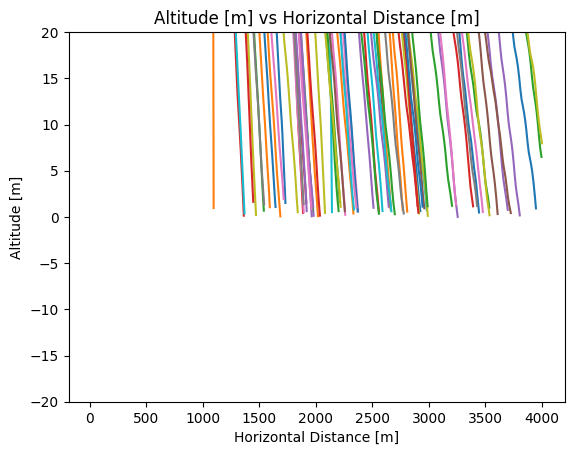

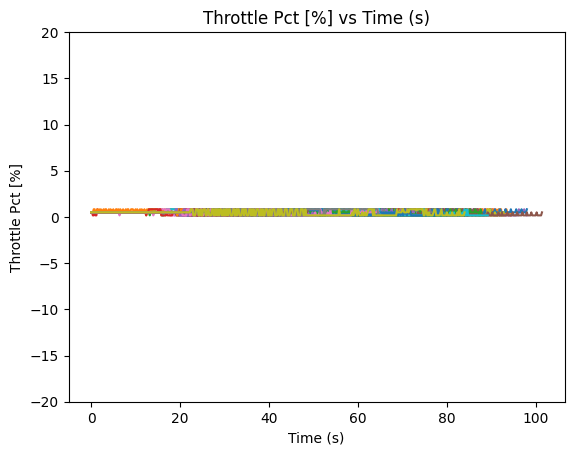

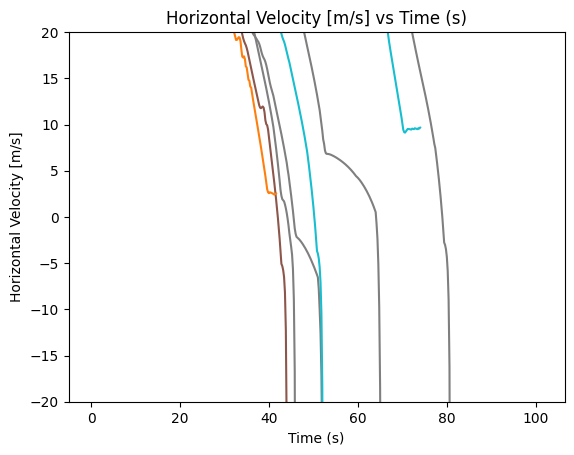

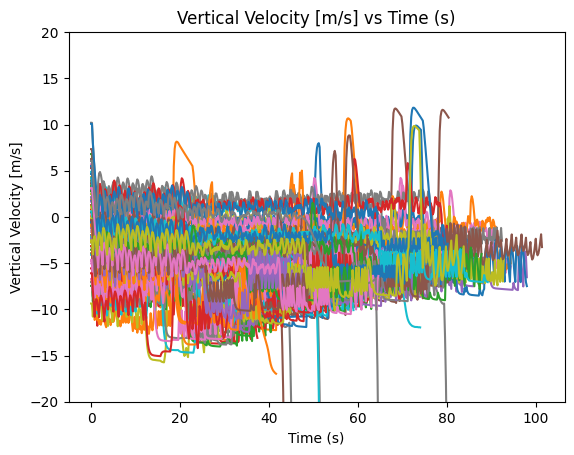

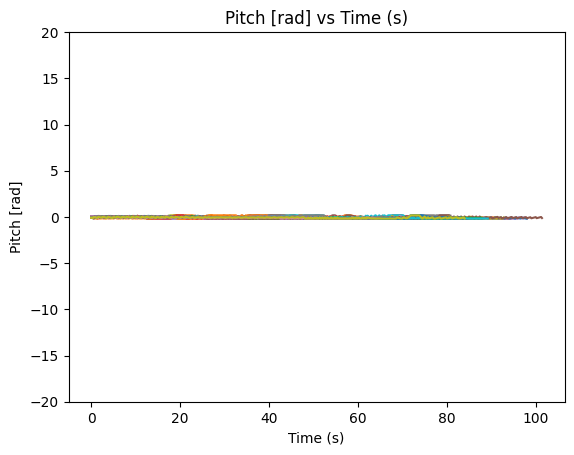

In [74]:
plot_two_vars("x", "y")
plot_two_vars("t", "throttle")
plot_two_vars("t", "vx")
plot_two_vars("t", "vy")
plot_two_vars("t", "theta")